Here, we first implement the distance 3 surface code and do some measurements.

In [3]:
# function to calculate inital rotation to give to qubits in the surface code

import numpy as np

def physical_angle(logical_angle_in_pi: float, num_physical_rotations: int) -> float:
    """
    Compute the physical rotation angle needed to achieve a logical rotation of
    angle `logical_angle_in_pi` on `num_physical_rotations` physical rotations.

    Args:
        logical_angle_in_pi (float): The logical rotation angle in units of pi.
        num_physical_rotations (int): The number of physical rotations that are applied.
    Returns:
        float: The physical rotation angle in units of pi.
    """

    assert (
        num_physical_rotations % 2 == 1 and num_physical_rotations > 0
    ), "k must be a positive odd integer"
    sign = -1 if (num_physical_rotations + 1) % 4 == 0 else 1
    logical_angle_in_rad = logical_angle_in_pi * np.pi
    x = np.tan(logical_angle_in_rad / 2) ** (1 / num_physical_rotations)
    theta_phys = 2 * np.arctan(x)
    return float(sign * theta_phys / np.pi)



In [ ]:
# test output to view the configuration of the surface code (used for counting measure modules)

import tsim
stim_path = f"assets/star_circuits/star_d={7}.stim"
c = tsim.Circuit.from_file(stim_path)
c.without_noise().diagram("timeslice-svg", height=500*3, rows=8)



In [ ]:
# ─── Config for D = 3 ───────────────────────────────────────────────────────────────────
angles_to_test          = [0.0001, 0.0004, 0.002, 0.007, 0.03, 0.1, 0.5, 1.0]
distance                = 3
n_trials                = 5000
first_k_detectors       = 20
line_A                  = 105
line_B                  = 317
stim_path               = f"assets/star_circuits/star_d={distance}.stim"

lr                      = 0.01
epochs                  = 2000
max_weight_norm         = 10.0
train_frac              = 0.8
rng                     = np.random.default_rng(42)

# ─── Numerically stable sigmoid ───────────────────────────────────────────────
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return np.where(z >= 0,
                    1.0 / (1.0 + np.exp(-z)),
                    np.exp(z) / (1.0 + np.exp(z)))

# ─── Simulate all angles ───────────────────────────────────────────────────────
with open(stim_path, "r", encoding="utf-8") as f:
    original_lines = f.readlines()

detectors_list, logical_bit_list, physical_angles = [], [], []

try:
    for angle in angles_to_test:
        phys_angle = physical_angle(angle, distance)
        physical_angles.append(phys_angle)

        lines = original_lines.copy()
        lines[line_A - 1] = f"R_Z({phys_angle}) 0 3 6\n"
        lines[line_B - 1] = f"R_Z({-angle}) 6\n"

        with open(stim_path, "w", encoding="utf-8") as f:
            f.writelines(lines)

        c = tsim.Circuit.from_file(stim_path)
        detectors, logical_bit = c.compile_detector_sampler().sample(
            n_trials, separate_observables=True
        )

        keep = ~np.any(detectors[:, :min(first_k_detectors, detectors.shape[1])], axis=1)
        print(f"Angle {angle}: {keep.sum()}/{n_trials} shots survived post-selection")

        detectors_list.append(detectors[keep])
        logical_bit_list.append(logical_bit[keep])
finally:
    with open(stim_path, "w", encoding="utf-8") as f:
        f.writelines(original_lines)

detectors_all  = np.concatenate(detectors_list,  axis=0)
logical_bit_all = np.concatenate(logical_bit_list, axis=0)
print(f"detectors_all: {detectors_all.shape}, logical_bit_all: {logical_bit_all.shape}")

# ─── Prepare training data (train on ALL angles) ───────────────────────────────
X = detectors_all.astype(np.float64)
y = logical_bit_all.reshape(-1).astype(np.int64)

perm   = rng.permutation(len(X))
X, y   = X[perm], y[perm]
n_train = int(train_frac * len(X))
X_train, X_eval = X[:n_train], X[n_train:]
y_train, y_eval = y[:n_train], y[n_train:]

mu    = X_train.mean(axis=0, keepdims=True)
sigma = X_train.std(axis=0,  keepdims=True) + 1e-8
X_train = np.clip((X_train - mu) / sigma, -10, 10)
X_eval  = np.clip((X_eval  - mu) / sigma, -10, 10)

# ─── REINFORCE training ────────────────────────────────────────────────────────
w = np.zeros(X_train.shape[1], dtype=np.float64)
b = 0.0

for epoch in range(epochs):
    p1      = sigmoid(X_train @ w + b)
    actions = (rng.random(len(p1)) < p1).astype(np.int64)
    rewards = (actions == y_train).astype(np.float64)
    delta   = (rewards - rewards.mean()) * (actions - p1)

    w += lr * (X_train.T @ delta) / len(X_train)
    b += lr * delta.mean()

    # Prevent weight explosion
    norm = np.linalg.norm(w)
    if norm > max_weight_norm:
        w *= max_weight_norm / norm

    if (epoch + 1) % 200 == 0:
        train_acc = (( sigmoid(X_train @ w + b) >= 0.5) == y_train).mean()
        eval_acc  = ((sigmoid(X_eval  @ w + b) >= 0.5) == y_eval ).mean()
        print(f"Epoch {epoch+1:4d} | train={train_acc:.4f} | eval={eval_acc:.4f}")

# ─── Evaluate per angle ────────────────────────────────────────────────────────
samples_per_angle    = [len(d) for d in detectors_list]   # actual surviving counts
error_rate_per_angle = np.full(len(angles_to_test), np.nan)

offset = 0
for i, (angle, n_samples) in enumerate(zip(angles_to_test, samples_per_angle)):
    if n_samples == 0:
        print(f"Angle {angle}: no samples survived, skipping")
        continue

    # Pull the (shuffled) rows that belong to this angle from the permuted arrays
    X_i = np.clip((detectors_all[offset:offset+n_samples].astype(np.float64) - mu) / sigma, -10, 10)
    y_i = logical_bit_all[offset:offset+n_samples].reshape(-1).astype(np.int64)
    offset += n_samples

    pred_i = (sigmoid(X_i @ w + b) >= 0.5).astype(np.int64)
    error_rate_per_angle[i] = (pred_i != y_i).mean()

print("\nAngles:     ", angles_to_test)
print("Error rates:", error_rate_per_angle)
print("Error/d:    ", error_rate_per_angle / distance)

Angle 0.0001: 4129/5000 shots survived post-selection
Angle 0.0004: 4026/5000 shots survived post-selection
Angle 0.002: 3837/5000 shots survived post-selection
Angle 0.007: 3578/5000 shots survived post-selection
Angle 0.03: 2907/5000 shots survived post-selection
Angle 0.1: 1970/5000 shots survived post-selection
Angle 0.5: 1049/5000 shots survived post-selection
Angle 1.0: 4197/5000 shots survived post-selection
detectors_all: (25693, 56), logical_bit_all: (25693, 1)
Epoch  200 | train=0.9642 | eval=0.9636
Epoch  400 | train=0.9648 | eval=0.9636


/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_18402/1813433109.py:79: RuntimeWarning: divide by zero encountered in matmul
  p1      = sigmoid(X_train @ w + b)
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_18402/1813433109.py:79: RuntimeWarning: overflow encountered in matmul
  p1      = sigmoid(X_train @ w + b)
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_18402/1813433109.py:79: RuntimeWarning: invalid value encountered in matmul
  p1      = sigmoid(X_train @ w + b)
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_18402/1813433109.py:84: RuntimeWarning: divide by zero encountered in matmul
  w += lr * (X_train.T @ delta) / len(X_train)
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_18402/1813433109.py:84: RuntimeWarning: overflow encountered in matmul
  w += lr * (X_train.T @ delta) / len(X_train)
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_18402/1813433109.py:84: RuntimeWarning: invalid value encountered in 

Epoch  600 | train=0.9671 | eval=0.9656
Epoch  800 | train=0.9674 | eval=0.9659
Epoch 1000 | train=0.9675 | eval=0.9648
Epoch 1200 | train=0.9680 | eval=0.9652
Epoch 1400 | train=0.9688 | eval=0.9658
Epoch 1600 | train=0.9692 | eval=0.9661
Epoch 1800 | train=0.9688 | eval=0.9669
Epoch 2000 | train=0.9687 | eval=0.9671

Angles:      [0.0001, 0.0004, 0.002, 0.007, 0.03, 0.1, 0.5, 1.0]
Error rates: [0.02470332 0.02856433 0.02580141 0.03186138 0.02958376 0.03908629
 0.05815062 0.0378842 ]
Error/d:     [0.00823444 0.00952144 0.00860047 0.01062046 0.00986125 0.01302876
 0.01938354 0.01262807]


/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_18402/1813433109.py:112: RuntimeWarning: divide by zero encountered in matmul
  pred_i = (sigmoid(X_i @ w + b) >= 0.5).astype(np.int64)
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_18402/1813433109.py:112: RuntimeWarning: overflow encountered in matmul
  pred_i = (sigmoid(X_i @ w + b) >= 0.5).astype(np.int64)
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_18402/1813433109.py:112: RuntimeWarning: invalid value encountered in matmul
  pred_i = (sigmoid(X_i @ w + b) >= 0.5).astype(np.int64)


In [ ]:
# ─── Config for D = 5 ───────────────────────────────────────────────────────────────────
angles_to_test    = [0.0001, 0.0004, 0.002, 0.007, 0.03, 0.1, 0.5]
distance          = 5
n_trials          = 5000
first_k_detectors = 120
line_A            = 130
line_B            = 531
stim_path         = f"assets/star_circuits/star_d={distance}.stim"

lr                = 0.01
epochs            = 5000
max_weight_norm   = 10.0
train_frac        = 0.8
rng               = np.random.default_rng(42)

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return np.where(z >= 0,
                    1.0 / (1.0 + np.exp(-z)),
                    np.exp(z) / (1.0 + np.exp(z)))

# ─── Simulate all angles ───────────────────────────────────────────────────────
with open(stim_path, "r", encoding="utf-8") as f:
    original_lines = f.readlines()

detectors_list, logical_bit_list, physical_angles = [], [], []

try:
    for angle in angles_to_test:
        phys_angle = physical_angle(angle, distance)
        physical_angles.append(phys_angle)

        lines = original_lines.copy()
        lines[line_A - 1] = f"R_Z({phys_angle}) 0 5 10 15 20\n"
        lines[line_B - 1] = f"R_Z({-angle}) 20\n"

        with open(stim_path, "w", encoding="utf-8") as f:
            f.writelines(lines)

        detectors, logical_bit = (
            tsim.Circuit.from_file(stim_path)
                .compile_detector_sampler()
                .sample(n_trials, separate_observables=True)
        )

        k = min(first_k_detectors, detectors.shape[1])
        keep = ~np.any(detectors[:, :k], axis=1)
        print(f"Angle {angle}: {keep.sum()}/{n_trials} shots survived post-selection")

        detectors_list.append(detectors[keep])
        logical_bit_list.append(logical_bit[keep])
finally:
    with open(stim_path, "w", encoding="utf-8") as f:
        f.writelines(original_lines)

detectors_all   = np.concatenate(detectors_list,   axis=0)
logical_bit_all = np.concatenate(logical_bit_list, axis=0)
print(f"detectors_all: {detectors_all.shape}, logical_bit_all: {logical_bit_all.shape}")

# ─── Prepare training data ─────────────────────────────────────────────────────
X = detectors_all.astype(np.float64)
y = logical_bit_all.reshape(-1).astype(np.int64)

perm            = rng.permutation(len(X))
X, y            = X[perm], y[perm]
n_train         = int(train_frac * len(X))
X_train, X_eval = X[:n_train], X[n_train:]
y_train, y_eval = y[:n_train], y[n_train:]

mu    = X_train.mean(axis=0, keepdims=True)
sigma = X_train.std(axis=0,  keepdims=True) + 1e-8
X_train = np.clip((X_train - mu) / sigma, -10, 10)
X_eval  = np.clip((X_eval  - mu) / sigma, -10, 10)

# ─── REINFORCE ────────────────────────────────────────────────────────────────
w = np.zeros(X_train.shape[1], dtype=np.float64)
b = 0.0

for epoch in range(epochs):
    p1      = sigmoid(X_train @ w + b)
    actions = (rng.random(len(p1)) < p1).astype(np.int64)
    rewards = (actions == y_train).astype(np.float64)
    delta   = (rewards - rewards.mean()) * (actions - p1)

    w += lr * (X_train.T @ delta) / len(X_train)
    b += lr * delta.mean()

    norm = np.linalg.norm(w)
    if norm > max_weight_norm:
        w *= max_weight_norm / norm

    if (epoch + 1) % 200 == 0:
        train_acc = ((sigmoid(X_train @ w + b) >= 0.5) == y_train).mean()
        eval_acc  = ((sigmoid(X_eval  @ w + b) >= 0.5) == y_eval ).mean()
        print(f"Epoch {epoch+1:4d} | train={train_acc:.4f} | eval={eval_acc:.4f}")

eval_acc = ((sigmoid(X_eval @ w + b) >= 0.5) == y_eval).mean()
print(f"\nFinal eval accuracy: {eval_acc:.4f}")
print(f"Positive rate — labels: {y_eval.mean():.4f} | "
      f"predictions: {((sigmoid(X_eval @ w + b) >= 0.5)).mean():.4f}")

# ─── Per-angle error rates ─────────────────────────────────────────────────────
samples_per_angle    = [len(d) for d in detectors_list]  # actual post-selection counts
error_rate_per_angle = np.full(len(angles_to_test), np.nan)

offset = 0
for i, (angle, n_samples) in enumerate(zip(angles_to_test, samples_per_angle)):
    if n_samples == 0:
        print(f"Angle {angle}: no samples survived, skipping")
        offset += n_samples
        continue

    X_i = np.clip(
        (detectors_all[offset:offset + n_samples].astype(np.float64) - mu) / sigma,
        -10, 10
    )
    y_i = logical_bit_all[offset:offset + n_samples].reshape(-1).astype(np.int64)
    offset += n_samples

    error_rate_per_angle[i] = (
        (sigmoid(X_i @ w + b) >= 0.5).astype(np.int64) != y_i
    ).mean()

print("\nAngles:     ", angles_to_test)
print("Error rates:", error_rate_per_angle)
print("Error/d:    ", error_rate_per_angle / distance)

Angle 0.0001: 1815/5000 shots survived post-selection
Angle 0.0004: 1723/5000 shots survived post-selection
Angle 0.002: 1319/5000 shots survived post-selection
Angle 0.007: 1013/5000 shots survived post-selection
Angle 0.03: 579/5000 shots survived post-selection
Angle 0.1: 315/5000 shots survived post-selection
Angle 0.5: 124/5000 shots survived post-selection
detectors_all: (6888, 216), logical_bit_all: (6888, 1)
Epoch  200 | train=0.9552 | eval=0.9565
Epoch  400 | train=0.9559 | eval=0.9550
Epoch  600 | train=0.9588 | eval=0.9565
Epoch  800 | train=0.9588 | eval=0.9601
Epoch 1000 | train=0.9606 | eval=0.9630


/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_23346/2131241409.py:80: RuntimeWarning: divide by zero encountered in matmul
  p1      = sigmoid(X_train @ w + b)
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_23346/2131241409.py:80: RuntimeWarning: overflow encountered in matmul
  p1      = sigmoid(X_train @ w + b)
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_23346/2131241409.py:80: RuntimeWarning: invalid value encountered in matmul
  p1      = sigmoid(X_train @ w + b)
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_23346/2131241409.py:85: RuntimeWarning: divide by zero encountered in matmul
  w += lr * (X_train.T @ delta) / len(X_train)
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_23346/2131241409.py:85: RuntimeWarning: overflow encountered in matmul
  w += lr * (X_train.T @ delta) / len(X_train)
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_23346/2131241409.py:85: RuntimeWarning: invalid value encountered in 

Epoch 1200 | train=0.9606 | eval=0.9586
Epoch 1400 | train=0.9635 | eval=0.9623
Epoch 1600 | train=0.9646 | eval=0.9623
Epoch 1800 | train=0.9644 | eval=0.9623
Epoch 2000 | train=0.9652 | eval=0.9615
Epoch 2200 | train=0.9652 | eval=0.9644
Epoch 2400 | train=0.9641 | eval=0.9637
Epoch 2600 | train=0.9644 | eval=0.9637
Epoch 2800 | train=0.9639 | eval=0.9637
Epoch 3000 | train=0.9641 | eval=0.9637
Epoch 3200 | train=0.9628 | eval=0.9630
Epoch 3400 | train=0.9626 | eval=0.9630
Epoch 3600 | train=0.9642 | eval=0.9644
Epoch 3800 | train=0.9644 | eval=0.9644
Epoch 4000 | train=0.9644 | eval=0.9644
Epoch 4200 | train=0.9644 | eval=0.9644
Epoch 4400 | train=0.9644 | eval=0.9644
Epoch 4600 | train=0.9644 | eval=0.9644
Epoch 4800 | train=0.9646 | eval=0.9644
Epoch 5000 | train=0.9646 | eval=0.9644

Final eval accuracy: 0.9644
Positive rate — labels: 0.0341 | predictions: 0.0044

Angles:      [0.0001, 0.0004, 0.002, 0.007, 0.03, 0.1, 0.5]
Error rates: [0.03526171 0.03366222 0.030326   0.04343534

/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_23346/2131241409.py:97: RuntimeWarning: divide by zero encountered in matmul
  eval_acc = ((sigmoid(X_eval @ w + b) >= 0.5) == y_eval).mean()
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_23346/2131241409.py:97: RuntimeWarning: overflow encountered in matmul
  eval_acc = ((sigmoid(X_eval @ w + b) >= 0.5) == y_eval).mean()
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_23346/2131241409.py:97: RuntimeWarning: invalid value encountered in matmul
  eval_acc = ((sigmoid(X_eval @ w + b) >= 0.5) == y_eval).mean()
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_23346/2131241409.py:100: RuntimeWarning: divide by zero encountered in matmul
  f"predictions: {((sigmoid(X_eval @ w + b) >= 0.5)).mean():.4f}")
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_23346/2131241409.py:100: RuntimeWarning: overflow encountered in matmul
  f"predictions: {((sigmoid(X_eval @ w + b) >= 0.5)).mean():.4f}")
/v

In [ ]:
# ─── Config  for D = 7 ───────────────────────────────────────────────────────────────────
angles_to_test    = [0.0001, 0.0004, 0.002, 0.007, 0.03, 0.1, 0.5]
distance          = 7
n_trials          = 5000
first_k_detectors = 300 #96
line_A            = 202
line_B            = 945
stim_path         = f"assets/star_circuits/star_d={distance}.stim"

lr                = 0.01
epochs            = 5000
max_weight_norm   = 10.0
train_frac        = 0.8
rng               = np.random.default_rng(42)

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return np.where(z >= 0,
                    1.0 / (1.0 + np.exp(-z)),
                    np.exp(z) / (1.0 + np.exp(z)))

def cross_entropy_grad(X, y, w, b):
    from scipy.special import expit
    p   = expit(np.clip(X @ w + b, -500, 500))
    err = p - y
    return X.T @ err / len(y), err.mean()

# ─── Simulate all angles ───────────────────────────────────────────────────────
with open(stim_path, "r", encoding="utf-8") as f:
    original_lines = f.readlines()

detectors_list, logical_bit_list, physical_angles = [], [], []

try:
    for angle in angles_to_test:
        phys_angle = physical_angle(angle, distance)
        physical_angles.append(phys_angle)

        lines = original_lines.copy()
        lines[line_A - 1] = f"R_Z({phys_angle}) 0 7 14 21 28 35 42\n"
        lines[line_B - 1] = f"R_Z({-angle}) 42\n"

        with open(stim_path, "w", encoding="utf-8") as f:
            f.writelines(lines)

        detectors, logical_bit = (
            tsim.Circuit.from_file(stim_path)
                .compile_detector_sampler()
                .sample(n_trials, separate_observables=True)
        )

        k    = min(first_k_detectors, detectors.shape[1])
        keep = ~np.any(detectors[:, :k], axis=1)
        print(f"Angle {angle}: {keep.sum()}/{n_trials} shots survived post-selection")

        detectors_list.append(detectors[keep])
        logical_bit_list.append(logical_bit[keep])
finally:
    with open(stim_path, "w", encoding="utf-8") as f:
        f.writelines(original_lines)

detectors_all   = np.concatenate(detectors_list,   axis=0)
logical_bit_all = np.concatenate(logical_bit_list, axis=0)
print(f"detectors_all: {detectors_all.shape}, logical_bit_all: {logical_bit_all.shape}")

# ─── Prepare training data ─────────────────────────────────────────────────────
X = detectors_all.astype(np.float64)
y = logical_bit_all.reshape(-1).astype(np.int64)

perm            = rng.permutation(len(X))
X, y            = X[perm], y[perm]
n_train         = int(train_frac * len(X))
X_train, X_eval = X[:n_train], X[n_train:]
y_train, y_eval = y[:n_train], y[n_train:]

mu    = X_train.mean(axis=0, keepdims=True)
sigma = X_train.std(axis=0,  keepdims=True) + 1e-8
X_train = np.clip((X_train - mu) / sigma, -10, 10)
X_eval  = np.clip((X_eval  - mu) / sigma, -10, 10)

# ─── Cross-entropy training (replaces REINFORCE) ───────────────────────────────
w = np.zeros(X_train.shape[1], dtype=np.float64)
b = 0.0

for epoch in range(epochs):
    gw, gb = cross_entropy_grad(X_train, y_train, w, b)
    w -= lr * gw
    b -= lr * gb

    norm = np.linalg.norm(w)
    if norm > max_weight_norm:
        w *= max_weight_norm / norm

    if (epoch + 1) % 200 == 0:
        train_acc = ((sigmoid(X_train @ w + b) >= 0.5) == y_train).mean()
        eval_acc  = ((sigmoid(X_eval  @ w + b) >= 0.5) == y_eval ).mean()
        print(f"Epoch {epoch+1:4d} | train={train_acc:.4f} | eval={eval_acc:.4f}")

eval_acc = ((sigmoid(X_eval @ w + b) >= 0.5) == y_eval).mean()
print(f"\nFinal eval accuracy: {eval_acc:.4f}")
print(f"Positive rate — labels: {y_eval.mean():.4f} | "
      f"predictions: {(sigmoid(X_eval @ w + b) >= 0.5).mean():.4f}")

# ─── Per-angle error rates ─────────────────────────────────────────────────────
samples_per_angle    = [len(d) for d in detectors_list]
error_rate_per_angle = np.full(len(angles_to_test), np.nan)

offset = 0
for i, (angle, n_samples) in enumerate(zip(angles_to_test, samples_per_angle)):
    if n_samples == 0:
        print(f"Angle {angle}: no samples survived, skipping")
        offset += n_samples
        continue

    X_i = np.clip(
        (detectors_all[offset:offset + n_samples].astype(np.float64) - mu) / sigma,
        -10, 10
    )
    y_i = logical_bit_all[offset:offset + n_samples].reshape(-1).astype(np.int64)
    offset += n_samples

    error_rate_per_angle[i] = (
        (sigmoid(X_i @ w + b) >= 0.5).astype(np.int64) != y_i
    ).mean()

print("\nAngles:     ", angles_to_test)
print("Error rates:", error_rate_per_angle)
print("Error/d:    ", error_rate_per_angle / distance)


Angle 0.0001: 387/5000 shots survived post-selection
Angle 0.0004: 326/5000 shots survived post-selection
Angle 0.002: 212/5000 shots survived post-selection
Angle 0.007: 151/5000 shots survived post-selection
Angle 0.03: 59/5000 shots survived post-selection
Angle 0.1: 25/5000 shots survived post-selection
Angle 0.5: 11/5000 shots survived post-selection
detectors_all: (1171, 528), logical_bit_all: (1171, 1)
Epoch  200 | train=0.9658 | eval=0.9277
Epoch  400 | train=0.9712 | eval=0.9404
Epoch  600 | train=0.9722 | eval=0.9489
Epoch  800 | train=0.9733 | eval=0.9447
Epoch 1000 | train=0.9733 | eval=0.9447
Epoch 1200 | train=0.9733 | eval=0.9447
Epoch 1400 | train=0.9744 | eval=0.9447
Epoch 1600 | train=0.9754 | eval=0.9447
Epoch 1800 | train=0.9754 | eval=0.9404
Epoch 2000 | train=0.9754 | eval=0.9404
Epoch 2200 | train=0.9765 | eval=0.9447
Epoch 2400 | train=0.9765 | eval=0.9447
Epoch 2600 | train=0.9765 | eval=0.9404
Epoch 2800 | train=0.9765 | eval=0.9404
Epoch 3000 | train=0.9765 |

/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_23346/2459203815.py:26: RuntimeWarning: divide by zero encountered in matmul
  p   = expit(np.clip(X @ w + b, -500, 500))
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_23346/2459203815.py:26: RuntimeWarning: overflow encountered in matmul
  p   = expit(np.clip(X @ w + b, -500, 500))
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_23346/2459203815.py:26: RuntimeWarning: invalid value encountered in matmul
  p   = expit(np.clip(X @ w + b, -500, 500))
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_23346/2459203815.py:28: RuntimeWarning: divide by zero encountered in matmul
  return X.T @ err / len(y), err.mean()
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_23346/2459203815.py:28: RuntimeWarning: overflow encountered in matmul
  return X.T @ err / len(y), err.mean()
/var/folders/zk/9fz9rkrs7zgd90bj9wqcpqr40000gn/T/ipykernel_23346/2459203815.py:28: RuntimeWarning: invalid value encou

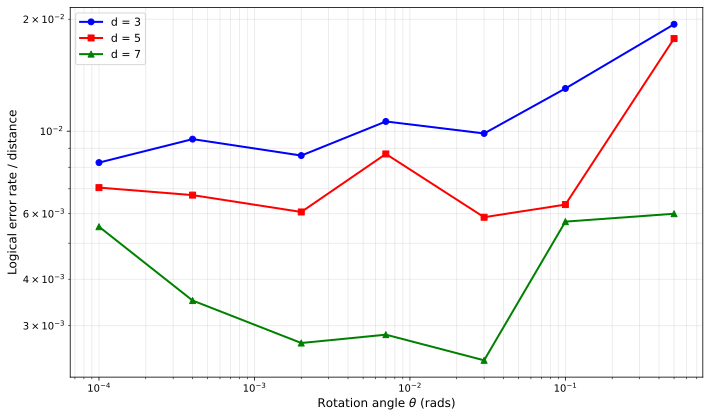

In [ ]:
# Graphing output for the data obtained earlier

import matplotlib.pyplot as plt

# Data from the three distances
angles = np.array([0.0001, 0.0004, 0.002, 0.007, 0.03, 0.1, 0.5])
error_d3 = np.array([0.00823444, 0.00952144, 0.00860047, 0.01062046, 0.00986125, 0.01302876, 0.01938354])
error_d5 = np.array([0.00705234, 0.00673244, 0.0060652, 0.00868707, 0.00587219, 0.00634921, 0.01774194])
error_d7 = np.array([0.0055371, 0.0035057, 0.00269542, 0.00283822, 0.00242131, 0.00571429, 0.006])

plt.figure(figsize=(10, 6))
plt.loglog(angles, error_d3, marker='o', color='blue', label='d = 3', linewidth=2)
plt.loglog(angles, error_d5, marker='s', color='red', label='d = 5', linewidth=2)
plt.loglog(angles, error_d7, marker='^', color='green', label='d = 7', linewidth=2)

plt.xlabel(r'Rotation angle $\theta$ (rads)', fontsize=12)
plt.ylabel('Logical error rate / distance', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()